In [1]:
import pandas as pd
import numpy as np

In [2]:
!pwd

/workspaces/machine-learning-zoomcamp/02-regression


Dataset
For this homework, we'll use the 2026 Car Fuel Efficiency dataset. Download it from here.
You can do it with wget:

In [3]:
!wget https://raw.githubusercontent.com/DataTalksClub/machine-learning-zoomcamp/main/cohorts/2026/data/car_fuel_efficiency_2026.csv

--2026-09-28 09:15:14--  https://raw.githubusercontent.com/DataTalksClub/machine-learning-zoomcamp/main/cohorts/2026/data/car_fuel_efficiency_2026.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.110.133, 185.199.111.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 635180 (620K) [text/plain]
Saving to: ‘car_fuel_efficiency_2026.csv’

car_fuel_efficiency 100%[===================>] 620.29K  --.-KB/s    in 0.008s  

2026-09-28 09:15:14 (75.1 MB/s) - ‘car_fuel_efficiency_2026.csv’ saved [635180/635180]



In [4]:
df = pd.read_csv('car_fuel_efficiency_2026.csv')

In [5]:
df.head()

,model_year,origin,fuel_type,drivetrain,num_doors,engine_displacement,num_cylinders,horsepower,vehicle_weight,acceleration,fuel_efficiency_mpg
0,2006,Europe,Gasoline,Front-wheel drive,4,2180,6,243.0,3870,NaN,31.9
1,2008,Europe,Diesel,Front-wheel drive,4,2390,6,272.0,4210,NaN,31.3
2,1996,Asia,Gasoline,Front-wheel drive,5,2320,6,267.0,4240,17.3,27.5
3,1989,Europe,Gasoline,Front-wheel drive,4,2130,6,258.0,4490,18.7,28.5
4,1994,USA,Diesel,Front-wheel drive,3,2580,7,304.0,4510,17.5,31.0


Preparing the dataset
Use only the following columns:
'engine_displacement',
'horsepower',
'vehicle_weight',
'model_year',
'fuel_efficiency_mpg'

In [6]:
columns = [
    'engine_displacement',
    'horsepower',
    'vehicle_weight',
    'model_year',
    'fuel_efficiency_mpg'
]

In [7]:
df = df[columns]

In [8]:
 df.head()

,engine_displacement,horsepower,vehicle_weight,model_year,fuel_efficiency_mpg
0,2180,243.0,3870,2006,31.9
1,2390,272.0,4210,2008,31.3
2,2320,267.0,4240,1996,27.5
3,2130,258.0,4490,1989,28.5
4,2580,304.0,4510,1994,31.0


EDA
Look at the fuel_efficiency_mpg variable. Does it have a long tail?

<Axes: xlabel='fuel_efficiency_mpg', ylabel='Count'>

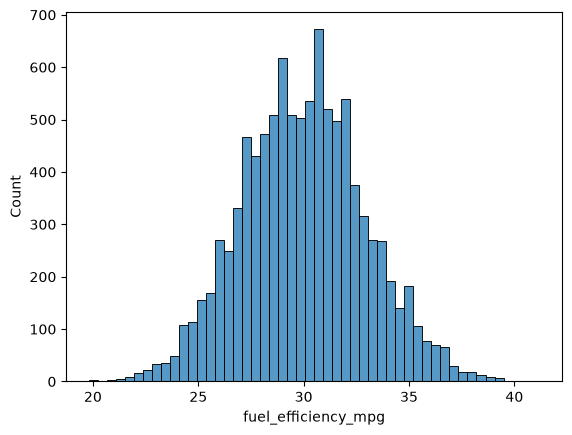

In [9]:
import seaborn as sns

sns.histplot(df.fuel_efficiency_mpg, bins=50)

It doesn't have a long tail.

Question 1
There's one column with missing values. What is it?

In [10]:
df.isnull().sum()

engine_displacement      0
horsepower             877
vehicle_weight           0
model_year               0
fuel_efficiency_mpg      0
dtype: int64

The column with missing values (877) is 'horsepower'

Question 2
What's the median (50% percentile) for variable 'horsepower'?

In [11]:
df.horsepower.describe().round(2)

count    9123.00
mean      254.45
std        22.84
min       171.00
25%       239.00
50%       254.00
75%       270.00
max       334.00
Name: horsepower, dtype: float64

The median (50% percentile) for variable 'horsepower' is 254.

Prepare and split the dataset
Shuffle the filtered dataset and create the split exactly as in the lecture:

In [12]:
n = len(df)
n_val = int(n * 0.2)
n_test = int(n * 0.2)
n_train = n - n_val - n_test

np.random.seed(42)
idx = np.arange(n)
np.random.shuffle(idx)

df_train = df.iloc[idx[:n_train]]
df_val = df.iloc[idx[n_train:n_train + n_val]]
df_test = df.iloc[idx[n_train + n_val:]]

In [13]:
len(df_train), len(df_val), len(df_test)

(6000, 2000, 2000)

In [14]:
df_train = df_train.reset_index(drop=True)
df_val = df_val.reset_index(drop=True)
df_test = df_test.reset_index(drop=True)

In [15]:
df_train.head()

,engine_displacement,horsepower,vehicle_weight,model_year,fuel_efficiency_mpg
0,1900,239.0,3790,2015,32.5
1,2000,224.0,4380,1992,29.1
2,2330,286.0,4090,2022,34.1
3,2300,NaN,4150,1997,30.6
4,2340,269.0,4400,2001,30.7


In [16]:
df_val.head()

,engine_displacement,horsepower,vehicle_weight,model_year,fuel_efficiency_mpg
0,2240,265.0,3990,2004,30.4
1,2390,259.0,4770,2019,32.8
2,2360,265.0,4320,2018,27.8
3,2430,279.0,4430,2008,28.6
4,2220,249.0,4030,1999,31.1


In [17]:
df_test.head()

,engine_displacement,horsepower,vehicle_weight,model_year,fuel_efficiency_mpg
0,2370,268.0,4410,1981,27.8
1,2240,256.0,4220,2020,37.3
2,2090,217.0,3910,2023,33.1
3,2280,251.0,4420,2021,31.3
4,2450,256.0,4420,1979,26.4


In [18]:
y_train = df_train.fuel_efficiency_mpg.values
y_val = df_val.fuel_efficiency_mpg.values
y_test = df_test.fuel_efficiency_mpg.values

In [19]:
del df_train['fuel_efficiency_mpg']
del df_val['fuel_efficiency_mpg']
del df_test['fuel_efficiency_mpg']

In [20]:
df_train.head()

,engine_displacement,horsepower,vehicle_weight,model_year
0,1900,239.0,3790,2015
1,2000,224.0,4380,1992
2,2330,286.0,4090,2022
3,2300,NaN,4150,1997
4,2340,269.0,4400,2001


In [21]:
df_val.head()

,engine_displacement,horsepower,vehicle_weight,model_year
0,2240,265.0,3990,2004
1,2390,259.0,4770,2019
2,2360,265.0,4320,2018
3,2430,279.0,4430,2008
4,2220,249.0,4030,1999


In [22]:
df_test.head()

,engine_displacement,horsepower,vehicle_weight,model_year
0,2370,268.0,4410,1981
1,2240,256.0,4220,2020
2,2090,217.0,3910,2023
3,2280,251.0,4420,2021
4,2450,256.0,4420,1979


Question 3
We need to deal with missing values for the column from Q1.
We have two options: fill it with 0 or with the mean of this variable.
Try both options. For each, train a linear regression model without regularization using the code from the lessons.
For computing the mean, use the training only!
Use the validation dataset to evaluate the models and compare the RMSE of each option.
Round the RMSE scores to 3 decimal digits using round(score, 3). This keeps the imputation difference visible in this release.
Which option gives better RMSE?

First, I fill it with 0:

In [23]:
df_val.isnull().sum()

engine_displacement      0
horsepower             176
vehicle_weight           0
model_year               0
dtype: int64

In [24]:
df_test.isnull().sum()

engine_displacement      0
horsepower             163
vehicle_weight           0
model_year               0
dtype: int64

In [25]:
df_train.isnull().sum()

engine_displacement      0
horsepower             538
vehicle_weight           0
model_year               0
dtype: int64

In [26]:
df_train0 = df_train.copy()

df_train0['horsepower'] = df_train0['horsepower'].fillna(0)   

X_train0= df_train0.values

X_train0.shape

(6000, 4)

In [27]:
df_train0.isnull().sum()


engine_displacement    0
horsepower             0
vehicle_weight         0
model_year             0
dtype: int64

In [28]:
df_val0 = df_val.copy()

df_val0['horsepower'] = df_val0['horsepower'].fillna(0)   

X_val0= df_val0.values

X_val0.shape

(2000, 4)

In [29]:
df_val0.isnull().sum()


engine_displacement    0
horsepower             0
vehicle_weight         0
model_year             0
dtype: int64

In [30]:
def train_linear_regression(X, y):
    ones = np.ones(X.shape[0])
    X = np.column_stack([ones, X])

    XTX = X.T.dot(X)
    XTX_inv = np.linalg.inv(XTX)
    w_full = XTX_inv.dot(X.T).dot(y)

    return w_full[0], w_full[1:]

In [31]:
w0, w = train_linear_regression(X_train0, y_train)

In [32]:
y_pred = w0 + X_val0.dot(w)

In [33]:
print(y_pred, w0, w)

[31.64502134 29.86572978 31.58838899 ... 30.53133298 30.75085098
 31.62912778] -153.88496188223104 [-1.51505520e-03 -4.74024794e-06 -3.95418397e-03  1.02146785e-01]


In [34]:
def rmse(y, y_pred):
    se = (y - y_pred) ** 2
    mse = se.mean()
    return np.sqrt(mse)

In [35]:
score_zero = rmse(y_val, y_pred)

In [36]:
round(score_zero, 3)

np.float64(2.205)

Then, I fill it with the mean of this variable.

In [37]:
mean_hp = df_train['horsepower'].mean()

In [38]:
print(mean_hp)


254.46338337605272


In [39]:
df_train_mean = df_train.copy()

df_train_mean['horsepower'] = df_train_mean['horsepower'].fillna(mean_hp)   

X_train_mean= df_train_mean.values

X_train_mean.shape

(6000, 4)

In [40]:
df_train_mean.isnull().sum()


engine_displacement    0
horsepower             0
vehicle_weight         0
model_year             0
dtype: int64

In [41]:
w0, w = train_linear_regression(X_train_mean, y_train)

In [42]:
df_val_mean = df_val.copy()

df_val_mean['horsepower'] = df_val_mean['horsepower'].fillna(mean_hp)   

X_val_mean= df_val_mean.values

X_val_mean.shape

(2000, 4)

In [43]:
y_pred = w0 + X_val_mean.dot(w)

In [44]:
print(y_pred, w0, w)

[31.54288381 29.92505122 31.56459523 ... 30.54408311 30.85701236
 31.55313717] -153.29645639182718 [-0.00102386 -0.00648622 -0.00388828  0.10197897]


In [45]:
score_mean = rmse(y_val, y_pred)

In [46]:
round(score_mean, 3)

np.float64(2.202)

Here, the option that gives better RMSE is filling the missing values with the mean.

Question 4
Now let's train a regularized linear regression.
For this question, fill the NAs with 0.
Try different values of r from this list: [0, 0.01, 0.1, 1, 5, 10, 100].
Use RMSE to evaluate the model on the validation dataset.
Round the RMSE scores to 4 decimal digits. This keeps the small but real regularization differences visible instead of turning several choices into a tie.
Which r gives the best RMSE?
If multiple options give the same best RMSE, select the smallest r.

In [47]:
def train_linear_regression_reg(X, y, r):
    ones = np.ones(X.shape[0])
    X = np.column_stack([ones, X])

    XTX = X.T.dot(X)
    XTX = XTX + r * np.eye(XTX.shape[0])

    XTX_inv = np.linalg.inv(XTX)
    w_full = XTX_inv.dot(X.T).dot(y)

    return w_full[0], w_full[1:]

In [48]:
for r in [0, 0.01, 0.1, 1, 5, 10, 100]:
    w0, w = train_linear_regression_reg(X_train0, y_train, r)
    y_pred = w0 + X_val0.dot(w)
    score = rmse(y_val, y_pred)
    print("r:", r, "score:", round(score, 4))

r: 0 score: 2.2053
r: 0.01 score: 2.2058
r: 0.1 score: 2.2241
r: 1 score: 2.3492
r: 5 score: 2.4094
r: 10 score: 2.4195
r: 100 score: 2.4292


r = 0 gives the best (lowest) RMSE.

Question 5
We used seed 42 for splitting the data. Let's find out how selecting the seed influences our score.
Try different seed values: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9].
For each seed, do the train/validation/test split with 60%/20%/20% distribution.
Fill the missing values with 0 and train a model without regularization.
For each seed, evaluate the model on the validation dataset and collect the RMSE scores.
What's the standard deviation of all the scores? To compute the standard deviation, use np.std.
Round the result to 3 decimal digits (round(std, 3))

In [49]:
n = len(df)
n_val = int(n * 0.2)
n_test = int(n * 0.2)
n_train = n - n_val - n_test

scores = []
for seed in [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]:
    np.random.seed(seed)
    idx = np.arange(n)
    np.random.shuffle(idx)

    df_train = df.iloc[idx[:n_train]]
    df_val = df.iloc[idx[n_train:n_train + n_val]]
    df_test = df.iloc[idx[n_train + n_val:]]
    
    df_train = df_train.reset_index(drop=True)
    df_val = df_val.reset_index(drop=True)
    df_test = df_test.reset_index(drop=True)

    y_train = df_train.fuel_efficiency_mpg.values
    y_val = df_val.fuel_efficiency_mpg.values
    y_test = df_test.fuel_efficiency_mpg.values

    del df_train['fuel_efficiency_mpg']
    del df_val['fuel_efficiency_mpg']
    del df_test['fuel_efficiency_mpg']

    df_train = df_train.copy()
    df_train['horsepower'] = df_train['horsepower'].fillna(0)   
    X_train= df_train.values

    w0, w = train_linear_regression(X_train, y_train)
    
    df_val = df_val.copy()
    df_val['horsepower'] = df_val['horsepower'].fillna(0)   
    X_val= df_val.values

    y_pred = w0 + X_val.dot(w)

    scores.append(rmse(y_val, y_pred))

In [50]:
scores

[np.float64(2.2392041430461465),
 np.float64(2.2021128210838907),
 np.float64(2.163419778753095),
 np.float64(2.2043588768539144),
 np.float64(2.2018800943312926),
 np.float64(2.2457851509084974),
 np.float64(2.269721207952404),
 np.float64(2.190794599933433),
 np.float64(2.2166112016864443),
 np.float64(2.207036592817851)]

In [51]:
len(scores)

10

In [52]:
round(np.std(scores), 3)

np.float64(0.029)

The standard deviation of all the scores is 0.029.

Question 6
Split the dataset like previously, use seed 9.
Combine train and validation datasets.

In [53]:
n = len(df)
n_val = int(n * 0.2)
n_test = int(n * 0.2)
n_train = n - n_val - n_test

np.random.seed(9)
idx = np.arange(n)
np.random.shuffle(idx)

df_train = df.iloc[idx[:n_train]]
df_val = df.iloc[idx[n_train:n_train + n_val]]
df_test = df.iloc[idx[n_train + n_val:]]
    
df_train = df_train.reset_index(drop=True)
df_val = df_val.reset_index(drop=True)
df_test = df_test.reset_index(drop=True)

df_full_train = pd.concat([df_train, df_val])  

df_full_train = df_full_train.reset_index(drop=True)

y_full_train = df_full_train.fuel_efficiency_mpg.values
y_test = df_test.fuel_efficiency_mpg.values

del df_full_train['fuel_efficiency_mpg']
del df_test['fuel_efficiency_mpg']

len(df_train), len(df_val), len(df_full_train), len(df_test)

(6000, 2000, 8000, 2000)

In [54]:
len(y_full_train), len(y_test)

(8000, 2000)

Fill the missing values with 0 and train a model with r=0.001.
What's the RMSE on the test dataset?

In [55]:
df_full_train = df_full_train.copy()

df_full_train['horsepower'] = df_full_train['horsepower'].fillna(0)   

X_full_train= df_full_train.values

X_full_train.shape

(8000, 4)

In [56]:
df_test = df_test.copy()

df_test['horsepower'] = df_test['horsepower'].fillna(0)   

X_test= df_test.values

X_test.shape

(2000, 4)

In [57]:
w0, w = train_linear_regression_reg(X_full_train, y_full_train, r=0.001)

y_pred = w0 + X_test.dot(w)
rmse(y_test, y_pred)

np.float64(2.2358277471917636)

In [58]:
round(rmse(y_test, y_pred), 3)

np.float64(2.236)

On the test dataset, RMSE = 2.236